<center><ins><h1>Meta Data</h1></ins></center>

<h5>Definition:</h5>
<ul>
    <li>Volatile and Total suspended solids (VSS/TSS) are analytical parameters representing, loosely, the undissolved organic matter in a water sample. More technically, they are water quality parameters and a factor for growth.</li> 
    <li>Formula for TSS G/L = ((DRIEDFILTER_G - EMPTYFILTER_G) / VOLUME_ML) * 1000. TSS can be further used for sludge indices.</li>
    <li>Formula for VSS G/L = ((BURNEDFILTER_G - EMPTYFILTER_G + BLANKFILTER_G) / VOLUME_ML) * 1000.</li>
    <li>Import of only one big data frame .xlsx.</li>
</ul>

<center>
<img src="../images/eps-assays_device.png" alt="Device" width="225" height="300">
<img src="../images/eps-assays_diagram.png" alt="Diagram" width="533" height="300">
<img src="../images/eps-assays_example-graph.png" alt="Example-Graph" width="579" height="300">
</center>

###### **Author:** Cedric Hering-Peter
###### **Address:** AG Schulz / Botantical Institut / Am Botanischen Garten 5 / 24118 Kiel

# Imports

In [1]:
import os, sys

WORKSPACE = os.path.abspath(os.path.join(os.getcwd(), ".."))
if WORKSPACE not in sys.path:
    sys.path.insert(0, WORKSPACE)

from scripts import data_helper, plot_helper
import pandas as pd
import matplotlib.pyplot as plt

CONFIG = data_helper.load_config()
META_DATA = data_helper.load_meta_data(CONFIG)
plot_helper.set_config(CONFIG)

# Variables

In [2]:


# Show numeric output in decimal format e.g., 2.1514
pd.options.display.float_format = '{:,.4f}'.format

# Raw Data Import

In [3]:
# define data path
file_master = [data_helper.get_master_file_path(CONFIG, "tss_vss")]

# import raw data frame
raw_df = data_helper.import_raw_df_from(file_master)
raw_df.head()

,ID,EXPERIMENT_NAME,SAMPLE_NAME,TIME,BIO_REP,TEC_REP,FILTER_ID,EMPTYFILTER_G,VOLUME_ML,DRIEDFILTER_G,BURNEDFILTER_G,TEMP_TSS,NOTE
0,CH230710,AT,Control,0-h,1,1,2,0.0903,20,0.1161,0.0905,NaN,NaN
1,CH230907,AT,Control,0-h,3,1,213,0.0922,15,0.1115,0.0921,NaN,NaN
2,CH230802,AT,Control,0-h,2,1,86,0.0930,15,0.1095,0.0929,NaN,NaN
3,CH240116,BM,CoC,0-h,1,1,494,0.0910,15,0.0933,0.0909,NaN,NaN
4,CH240114,BM,CoC,0-h,3,1,496,0.0914,15,0.0939,0.0914,NaN,NaN


# Custom Data Cleaning

In [4]:
# Automatic data conversion by pandas
clean_df = raw_df.convert_dtypes()
# Custom data conversion
clean_df["SAMPLE_NAME"] = clean_df["SAMPLE_NAME"].astype("string")

# Clean from stock, reactor and test samples
clean_df = clean_df.drop(clean_df[clean_df["SAMPLE_NAME"].str.contains("Reactor", na=False)].index)
clean_df = clean_df.drop(clean_df[clean_df["SAMPLE_NAME"] == "Test"].index)

# Get and calculate mean VSS-Blank and drop blank afterwards off clean_df
blank_mean = (clean_df[clean_df["SAMPLE_NAME"] == "VSS-Blank"]["EMPTYFILTER_G"] - clean_df[clean_df["SAMPLE_NAME"] == "VSS-Blank"]["BURNEDFILTER_G"]).mean()
clean_df = clean_df.drop(clean_df[clean_df["NOTE"].str.contains("Blank", na=False) | clean_df["NOTE"].str.contains("Drop", na=False)].index)

clean_df.head()

,ID,EXPERIMENT_NAME,SAMPLE_NAME,TIME,BIO_REP,TEC_REP,FILTER_ID,EMPTYFILTER_G,VOLUME_ML,DRIEDFILTER_G,BURNEDFILTER_G,TEMP_TSS,NOTE
0,CH230710,AT,Control,0-h,1,1,2,0.0903,20,0.1161,0.0905,<NA>,NaN
1,CH230907,AT,Control,0-h,3,1,213,0.0922,15,0.1115,0.0921,<NA>,NaN
2,CH230802,AT,Control,0-h,2,1,86,0.0930,15,0.1095,0.0929,<NA>,NaN
3,CH240116,BM,CoC,0-h,1,1,494,0.0910,15,0.0933,0.0909,<NA>,NaN
4,CH240114,BM,CoC,0-h,3,1,496,0.0914,15,0.0939,0.0914,<NA>,NaN


# Data Calculation

In [5]:
# Initialize new data frame for calculation
calc_df = clean_df.iloc[:, 0:6]

# Calculate TSS
calc_df["TSS_BIOMASS_G"] = clean_df["DRIEDFILTER_G"] - clean_df["EMPTYFILTER_G"]
calc_df["TSS_G/L"] = (calc_df["TSS_BIOMASS_G"] / clean_df["VOLUME_ML"] * 1000).astype("Float64")
# Check if there were wrong values inserted for TSS calculation
if (calc_df["TSS_G/L"] < 0).any():
    logging.warning(f" {(calc_df['TSS_G/L'] < 0).count()} negative values were identified.")

# Prepare VSS Data
calc_df["VSS_BIOMASS_G"] = clean_df["BURNEDFILTER_G"] - clean_df["EMPTYFILTER_G"] + blank_mean # calculated from all VSS-Blanks in clean_df
# Filter for negative VSS values and set to 0
calc_df.loc[calc_df["VSS_BIOMASS_G"] < 0, ["VSS_BIOMASS_G"]] = 0
# Calculate VSS
calc_df["VSS_G/L"] = (calc_df["VSS_BIOMASS_G"] / clean_df["VOLUME_ML"] * 1000).astype("Float64")
# Check if there were wrong values inserted for TSS calculation
if (calc_df["VSS_G/L"] < 0).any():
    logging.warning(f" {(calc_df['VSS_G/L'] < 0).count()} negative values were identified.")

# Calculate TSS / VSS percentages
calc_df["TSS_%"] = (100 - ((calc_df["VSS_G/L"] / calc_df["TSS_G/L"]) * 100)).astype("Float64")
calc_df["VSS_%"] = ((calc_df["VSS_G/L"] / calc_df["TSS_G/L"]) * 100).astype("Float64")

calc_df.head()

,ID,EXPERIMENT_NAME,SAMPLE_NAME,TIME,BIO_REP,TEC_REP,TSS_BIOMASS_G,TSS_G/L,VSS_BIOMASS_G,VSS_G/L,TSS_%,VSS_%
0,CH230710,AT,Control,0-h,1,1,0.0258,1.2900,0.0012,0.0615,95.2309,4.7691
1,CH230907,AT,Control,0-h,3,1,0.0193,1.2867,0.0009,0.0620,95.1791,4.8209
2,CH230802,AT,Control,0-h,2,1,0.0165,1.1000,0.0009,0.0620,94.3610,5.6390
3,CH240116,BM,CoC,0-h,1,1,0.0023,0.1533,0.0009,0.0620,59.5463,40.4537
4,CH240114,BM,CoC,0-h,3,1,0.0025,0.1667,0.0010,0.0687,58.7826,41.2174


# Data File Export

In [7]:
# Export to raw data .xlsx file into each experiment output folder
unique_exps = META_DATA.EXPERIMENT_NAME.unique()
for exp in unique_exps:
    exp_df = calc_df[calc_df["EXPERIMENT_NAME"] == exp]
    file_name = data_helper.get_output_path(CONFIG, exp, "CH_" + exp + "_Raw-Data.xlsx")
    with pd.ExcelWriter(file_name, engine = "openpyxl", mode = "a", if_sheet_exists = "replace") as writer:
        exp_df.to_excel(writer, sheet_name = "Suspended-Solids", index = False)

# Data Visualization 
#### <url>https://saturncloud.io/blog/how-to-plot-multiple-graphs-in-a-for-loop-with-ipythonjupyter-notebook-and-pandas/</url>

           ID EXPERIMENT_NAME    SAMPLE_NAME TIME  BIO_REP  TEC_REP  \
501  CH230130              SC  T.albertanoae    -        1        1   
502  CH230130              SC  T.albertanoae    -        1        2   
503  CH230130              SC  T.albertanoae    -        1        3   
504  CH230130              SC       P.duplex    -        1        2   
505  CH230130              SC       P.duplex    -        1        1   
506  CH230130              SC       P.duplex    -        1        3   
507  CH230130              SC     E.texensis    -        1        3   
508  CH230130              SC     E.texensis    -        1        1   
509  CH230130              SC     E.texensis    -        1        2   
510  CH230130              SC     C.vulgaris    -        1        1   
511  CH230130              SC     C.vulgaris    -        1        2   
512  CH230130              SC     C.vulgaris    -        1        3   
513  CH230130              SC  C.reinhardtii    -        1        3   
514  C

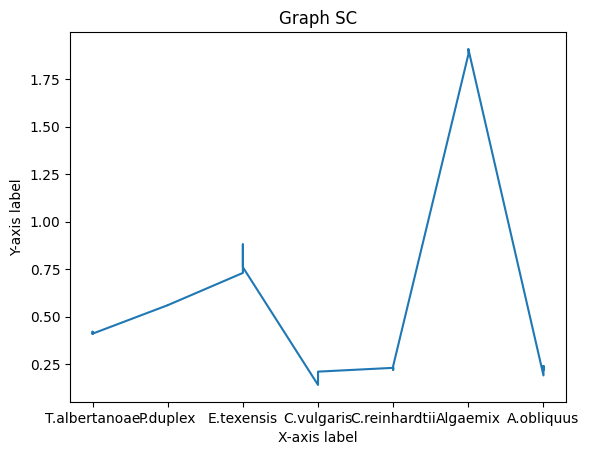

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
31   CH230708              ST     Control   0-h        1        1   
32   CH230905              ST     Control   0-h        3        1   
33   CH230800              ST     Control   0-h        2        1   
119  CH230708              ST     Control  12-h        1        1   
120  CH230905              ST     Control  12-h        3        1   
121  CH230800              ST     Control  12-h        2        1   
122  CH230708              ST          35  12-h        1        1   
123  CH230800              ST          35  12-h        2        1   
124  CH230905              ST          35  12-h        3        1   
128  CH230708              ST          15  12-h        1        1   
129  CH230905              ST          15  12-h        3        1   
130  CH230800              ST          15  12-h        2        1   
134  CH230708              ST         1.5  12-h        1        1   
135  CH230905              ST     

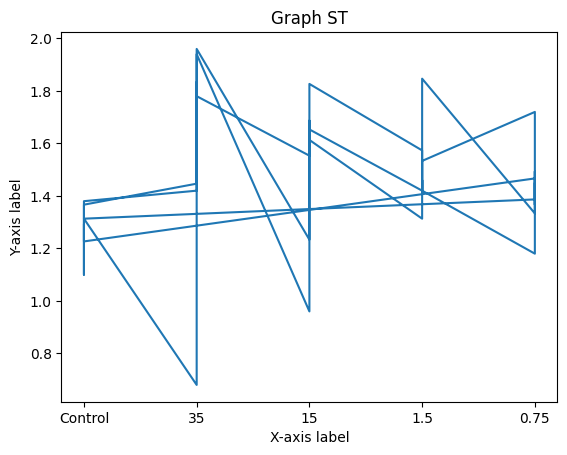

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
13   CH230709              PT     Control   0-h        1        1   
14   CH230906              PT     Control   0-h        3        1   
15   CH230801              PT     Control   0-h        2        1   
88   CH230906              PT     Control  12-h        3        1   
89   CH230709              PT     Control  12-h        1        1   
90   CH230801              PT     Control  12-h        2        1   
91   CH230906              PT          12  12-h        3        1   
92   CH230801              PT          12  12-h        2        1   
93   CH230709              PT          12  12-h        1        1   
94   CH230906              PT           9  12-h        3        1   
95   CH230709              PT           9  12-h        1        1   
96   CH230801              PT           9  12-h        2        1   
97   CH230709              PT           6  12-h        1        1   
98   CH230906              PT     

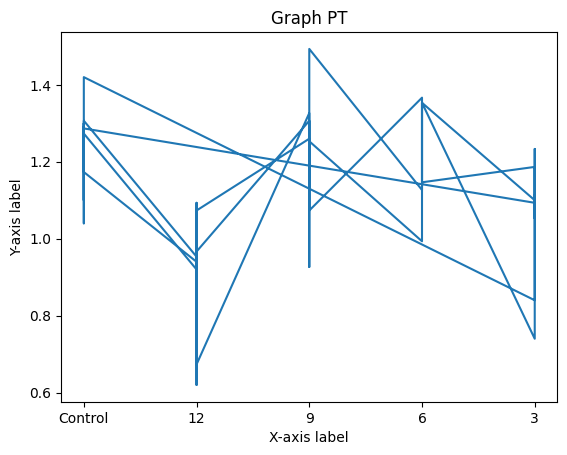

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
0    CH230710              AT     Control   0-h        1        1   
1    CH230907              AT     Control   0-h        3        1   
2    CH230802              AT     Control   0-h        2        1   
47   CH230710              AT     Control  12-h        1        1   
48   CH230907              AT     Control  12-h        3        1   
49   CH230802              AT     Control  12-h        2        1   
50   CH230710              AT         100  12-h        1        1   
51   CH230907              AT         100  12-h        3        1   
52   CH230802              AT         100  12-h        2        1   
53   CH230710              AT          10  12-h        1        1   
54   CH230802              AT          10  12-h        2        1   
55   CH230907              AT          10  12-h        3        1   
56   CH230907              AT           1  12-h        3        1   
57   CH230802              AT     

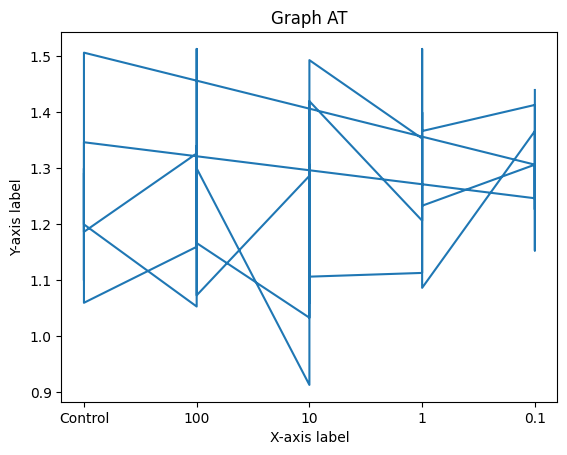

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
9    CH230807              LT     Control   0-h        2        1   
10   CH230724              LT     Control   0-h        1        1   
11   CH230914              LT     Control   0-h        3        1   
68   CH230807              LT     Control  12-h        2        1   
69   CH230724              LT     Control  12-h        1        1   
70   CH230914              LT     Control  12-h        3        1   
72   CH230914              LT         100  12-h        3        1   
73   CH230807              LT         100  12-h        2        1   
74   CH230724              LT         100  12-h        1        1   
76   CH230807              LT          70  12-h        2        1   
77   CH230914              LT          70  12-h        3        1   
78   CH230724              LT          70  12-h        1        1   
80   CH230914              LT          50  12-h        3        1   
81   CH230807              LT     

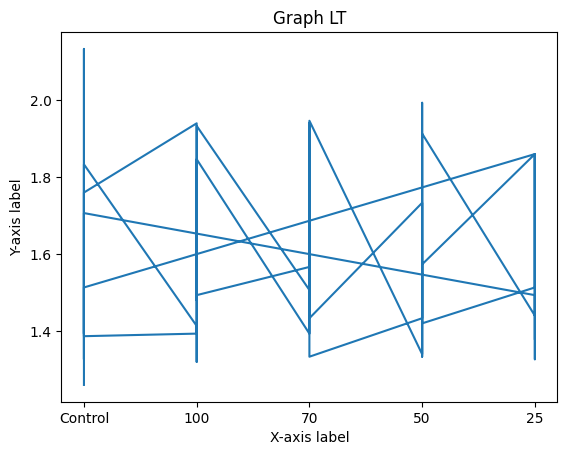

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
34   CH230912              TT     Control   0-h        3        1   
35   CH230809              TT     Control   0-h        2        1   
36   CH230726              TT     Control   0-h        1        1   
146  CH230912              TT     Control  12-h        3        1   
147  CH230809              TT     Control  12-h        2        1   
148  CH230726              TT     Control  12-h        1        1   
149  CH230912              TT          45  12-h        3        1   
150  CH230809              TT          45  12-h        2        1   
151  CH230726              TT          45  12-h        1        1   
152  CH230912              TT          35  12-h        3        1   
153  CH230809              TT          35  12-h        2        1   
154  CH230726              TT          35  12-h        1        1   
155  CH230912              TT          15  12-h        3        1   
156  CH230809              TT     

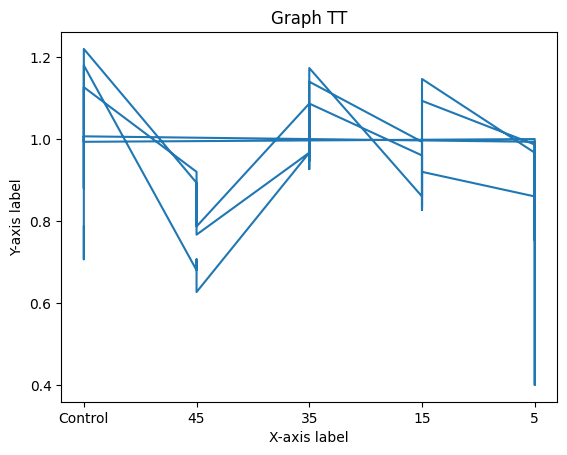

           ID EXPERIMENT_NAME SAMPLE_NAME TIME  BIO_REP  TEC_REP  \
476  CH230921              CC      RueBio    -        2        1   
477  CH230921              CC      RueBio    -        4        1   
478  CH230921              CC      RueBio    -        3        1   
479  CH230921              CC      RueBio    -        5        1   
480  CH230921              CC      RueBio    -        1        1   
481  CH230921              CC        OECD    -        4        1   
482  CH230921              CC        OECD    -        2        1   
483  CH230921              CC        OECD    -        5        1   
484  CH230921              CC        OECD    -        1        1   
485  CH230921              CC        OECD    -        3        1   
487  CH230921              CC       FEMAK    -        4        1   
488  CH230921              CC       FEMAK    -        5        1   
489  CH230921              CC       FEMAK    -        3        1   
490  CH230921              CC       FEMAK    -  

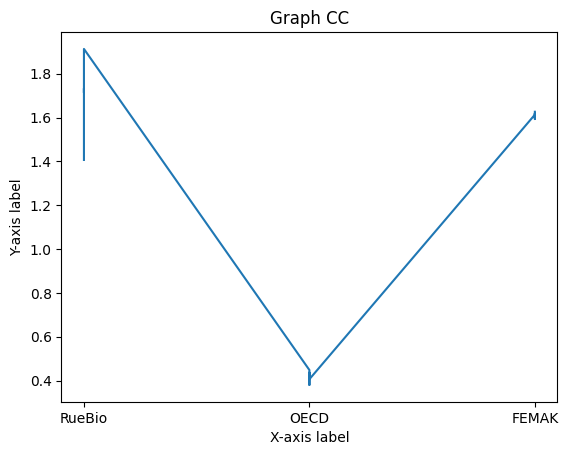

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
16   CH231216              RM          ET   0-h        1        1   
17   CH231214              RM          ET   0-h        3        1   
18   CH231215              RM          ET   0-h        2        1   
19   CH231215              RM     Control   0-h        2        1   
20   CH231214              RM     Control   0-h        3        1   
21   CH231216              RM     Control   0-h        1        1   
22   CH231216              RM          AT   0-h        1        1   
23   CH231214              RM          AT   0-h        3        1   
24   CH231215              RM          AT   0-h        2        1   
25   CH231216              RM        +EPS   0-h        1        1   
26   CH231214              RM        +EPS   0-h        3        1   
27   CH231215              RM        +EPS   0-h        2        1   
28   CH231216              RM        -EPS   0-h        1        1   
29   CH231214              RM     

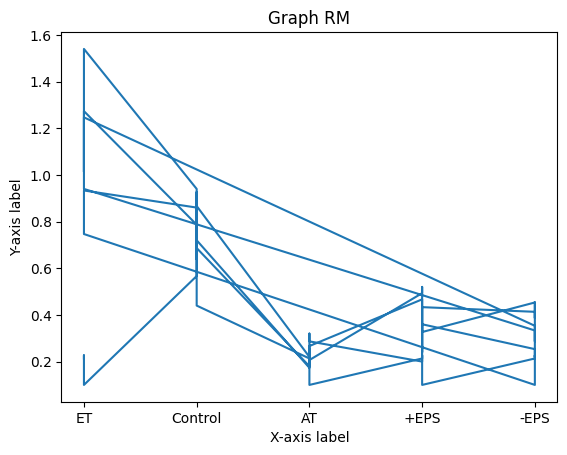

           ID EXPERIMENT_NAME SAMPLE_NAME  TIME  BIO_REP  TEC_REP  \
3    CH240116              BM         CoC   0-h        1        1   
4    CH240114              BM         CoC   0-h        3        1   
5    CH240115              BM         CoC   0-h        2        1   
6    CH240114              BM         CoA   0-h        3        1   
7    CH240116              BM         CoA   0-h        1        1   
8    CH240115              BM         CoA   0-h        2        1   
62   CH240116              BM         CoA  12-h        1        1   
63   CH240115              BM         CoA  12-h        2        1   
64   CH240114              BM         CoA  12-h        3        1   
65   CH240116              BM         AMC  12-h        1        1   
66   CH240115              BM         AMC  12-h        2        1   
67   CH240114              BM         AMC  12-h        3        1   
186  CH240115              BM         EPS  24-h        2        1   
187  CH240114              BM     

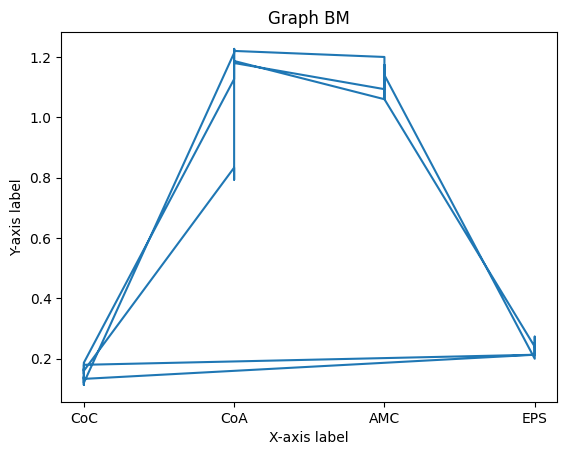

In [9]:
plot_df = calc_df # used data for plot creation

# TODO Possible to show off data with all values without mean() in box plot?
# TODO In theory works but only line plots -> need to progress in udemy course to make clean data visualization
unique_exps = META_DATA.EXPERIMENT_NAME.unique()
for exp in unique_exps:
    # TODO Group into dataframes by experiment_name and bio_rep
    subset = plot_df[plot_df["EXPERIMENT_NAME"] == exp]
    print(subset)
    plt.plot(subset["SAMPLE_NAME"], subset["TSS_G/L"])
    plt.title(f'Graph {exp}')
    plt.xlabel('X-axis label')
    plt.ylabel('Y-axis label')
    plt.show()

# TODO How to investigate multiple plots (click through after running?)